In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
import sys
print(sys.executable)

c:\Users\SIMON\AppData\Local\Programs\Python\Python312\python.exe


In [3]:
VOCAB_SIZE = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data()

In [4]:
print(len(x_train))
print(len(x_test))

25000
25000


In [5]:
print(x_train.shape)
print(x_test.shape)

(25000,)
(25000,)


In [6]:
print(x_test.shape)
print(x_train.shape)

(25000,)
(25000,)


In [7]:
word_index = imdb.get_word_index()
print(list(word_index.items())[:10])

[('fawn', 34701), ('tsukino', 52006), ('nunnery', 52007), ('sonja', 16816), ('vani', 63951), ('woods', 1408), ('spiders', 16115), ('hanging', 2345), ('woody', 2289), ('trawling', 52008)]


In [8]:
reverse_word_index = {
    value: key for key, value in word_index.items()
}

def decode_review(review):
    return " ".join(
        reverse_word_index.get(i - 3, "?")
        for i in review
				)

print(decode_review(x_train[0]))

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be

In [9]:
print(y_train[0])

1


In [10]:
print("Review:")
print(decode_review(x_train[0]))

print("\nSentiment:")
print("Positive" if y_train[0] == 1 else "Negative")

Review:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and s

In [11]:
review_lengths = [len(review) for review in x_train ]
print(min(review_lengths))
print(max(review_lengths))
print(np.mean(review_lengths))

11
2494
238.71364


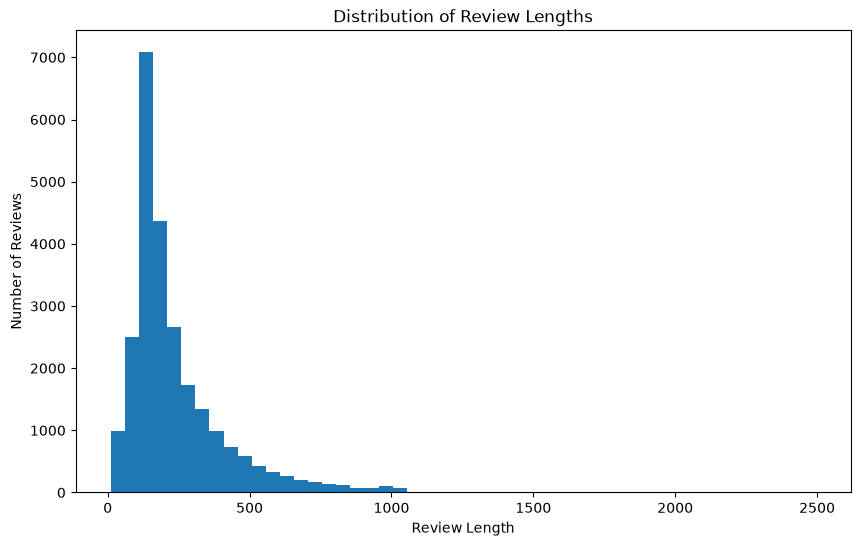

In [12]:
plt.figure(figsize=(10,6))
plt.hist(review_lengths, bins=50)
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths")
plt.show()

In [13]:
MAX_LEM = 200
x_train_pad = pad_sequences(
	x_train,
	maxlen=MAX_LEM,
	padding="post",
	truncating="post"
)

x_test_pad = pad_sequences(
	x_test,
	maxlen=MAX_LEM,
	padding="post",
	truncating="post"
)

In [14]:
print(x_train_pad.shape)
print(x_test_pad.shape)

(25000, 200)
(25000, 200)


In [15]:
from sklearn.feature_extraction.text import CountVectorizer

documents = [
	"movie was amazing",
	"movie was boring",
	"amazing movie",
	"boring movie"
]

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())
print(bow_matrix.toarray())

['amazing' 'boring' 'movie' 'was']
[[1 0 1 1]
 [0 1 1 1]
 [1 0 1 0]
 [0 1 1 0]]


In [16]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer()
tfidf_matrix = tfidf.fit_transform(bow_matrix)

print(vectorizer.get_feature_names_out())
print(tfidf_matrix.toarray())


['amazing' 'boring' 'movie' 'was']
[[0.64043405 0.         0.42389674 0.64043405]
 [0.         0.64043405 0.42389674 0.64043405]
 [0.83388421 0.         0.55193942 0.        ]
 [0.         0.83388421 0.55193942 0.        ]]


In [17]:
Embedding(
    input_dim=10000,
    output_dim=128,
    input_length=200
)

c:\Users\SIMON\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


<Embedding name=embedding, built=False>

In [18]:
VOCAB_SIZE = 10000
MAX_LEN = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

x_train_pad = pad_sequences(
	x_train,
	maxlen=MAX_LEN,
	padding="post",
	truncating="post"
)

x_test_pad = pad_sequences(
	x_test,
	maxlen=MAX_LEN,
	padding="post",
	truncating="post"
)

model = Sequential([
	Input(shape=(MAX_LEN,)),
	Embedding(
		input_dim=VOCAB_SIZE,
		output_dim=128,
		input_length=MAX_LEN
	),
	LSTM(128, dropout=0.2, recurrent_dropout=0.2),
	Dense(64, activation="relu"),
	Dropout(0.5),
	Dense(1, activation="sigmoid")
])

model.compile(
	optimizer="adam",
	loss="binary_crossentropy",
	metrics=["accuracy"]
)

history = model.fit(
	x_train_pad,
	y_train,
	epochs=5,
	batch_size=64,
	validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 220s 693ms/step - accuracy: 0.5209 - loss: 0.6928 - val_accuracy: 0.5168 - val_loss: 0.6877
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 181s 576ms/step - accuracy: 0.6109 - loss: 0.6543 - val_accuracy: 0.7600 - val_loss: 0.5438
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 180s 577ms/step - accuracy: 0.6775 - loss: 0.5984 - val_accuracy: 0.6608 - val_loss: 0.6324
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 172s 547ms/step - accuracy: 0.7521 - loss: 0.5349 - val_accuracy: 0.7084 - val_loss: 0.5960
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 193s 618ms/step - accuracy: 0.8160 - loss: 0.4595 - val_accuracy: 0.8132 - val_loss: 0.4719


In [ ]:
model.summary()

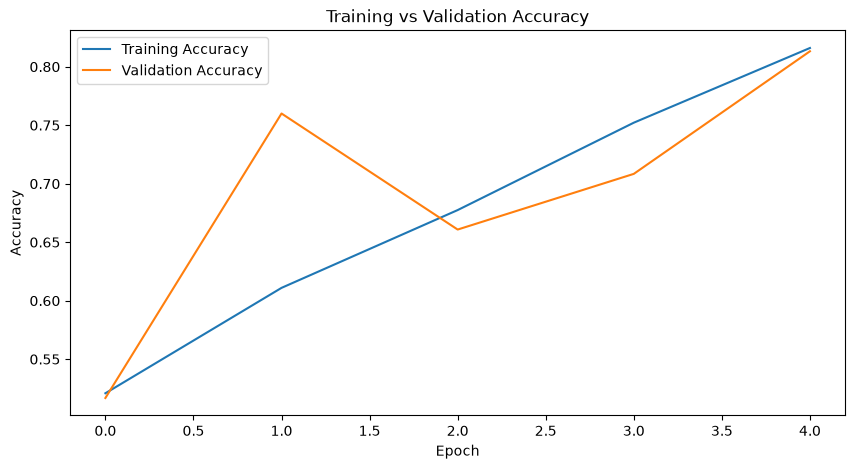

In [19]:
plt.figure(figsize=(10,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

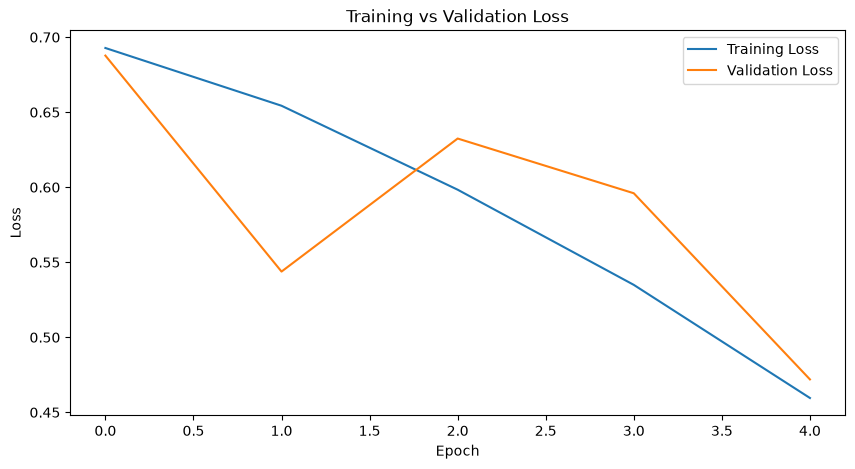

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [21]:
test_loss, test_accuracy = model.evaluate(x_train_pad, y_test, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.4935 - loss: 1.0713
Test Loss: 1.0712569952011108
Test Accuracy: 0.49351999163627625


In [22]:
y_probability = model.predict(x_test_pad)

782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step


In [23]:
y_pred = (y_probability >=0.5).astype(int).ravel()

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.80252


In [25]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.7760420468647347


In [26]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.85048


In [27]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.8115576930417191


In [28]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.83      0.75      0.79     12500
    Positive       0.78      0.85      0.81     12500

    accuracy                           0.80     25000
   macro avg       0.81      0.80      0.80     25000
weighted avg       0.81      0.80      0.80     25000



In [29]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 9432  3068]
 [ 1869 10631]]


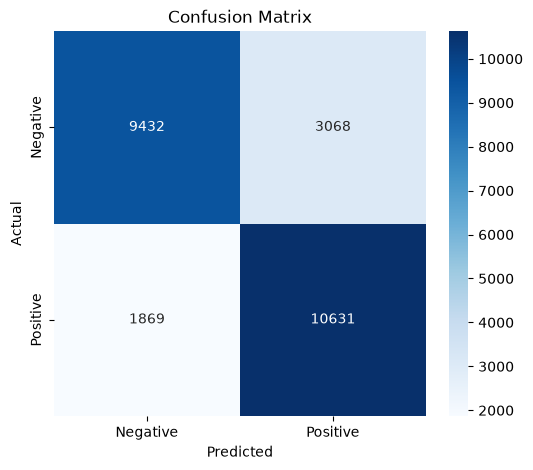

In [31]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [32]:
comparison = pd.DataFrame({
    "Actual": y_test[:20],
    "Predicted": y_pred[:20]
})

comparison["Actual Sentiment"] = comparison["Actual"].map({
    0: "Negative",
    1: "Positive"
})

comparison["Predicted Sentiment"] = comparison["Predicted"].map({
    0: "Negative",
    1: "Positive"
})

comparison

,Actual,Predicted,Actual Sentiment,Predicted Sentiment
0,0,0,Negative,Negative
1,1,1,Positive,Positive
2,1,1,Positive,Positive
3,0,1,Negative,Positive
4,1,1,Positive,Positive
5,1,1,Positive,Positive
6,1,0,Positive,Negative
7,0,0,Negative,Negative
8,0,1,Negative,Positive
9,1,1,Positive,Positive


In [33]:
def predict_sentiment(text):
	words = text.lower().split()
	sequence = []

	for word in words:
		index = word_index.get(word)

		if index is not None and index + 3 < VOCAB_SIZE:
			sequence.append(index + 3)
		else:
			sequence.append(2)  # unknown word

	padded = pad_sequences(
		[sequence],
		maxlen=MAX_LEN,
		padding="post",
		truncating="post"
	)

	probability = float(model.predict(padded, verbose=0)[0][0])
	sentiment = "Positive" if probability >= 0.5 else "Negative"

	return sentiment, probability
    
               

In [34]:
review = "This movie was amazing and excellent"

sentiment, probability = predict_sentiment(review)

print("Sentiment:", sentiment)
print("Probability:", probability)

Sentiment: Positive
Probability: 0.8525398969650269


In [35]:
model.save("sentiment_lstm_model.keras")